In [1]:
from spubase.data_access import Particles
import pandas as pd

# Initialize SpuBase

In [2]:
SpuBase = Particles(verbose=True, show_plot=False)  # create object (acts as 'self' and is used to call globals)

Model: sbbx
SW fraction is 96% H+ and 4% He2+
DB directory: C:\Users\couro\Dokumente\GitHub\SpuBase\spubase\docs


#### Data

In [3]:
oxide_comp_df = pd.read_csv('../input/Lunar_compositions.csv', index_col='sample')
SpuBase.casename = oxide_comp_df.index.tolist()[0]  # for demonstration purposes we only run the first composition

#### Optional Inputs

In [4]:
# SpuBase.update_file_format('pdf') # plot format, choose between 'pdf', 'png', 'svg', 'tiff'
# SpuBase.update_impactor('H', comp_frac=[1.00, 0.00])  # either 1 keV H ('H'), 4 keV He ('He') or both ('SW'); comp_frac: different mixture of H, He (Significantly effects yield and angular distribution!)
# SpuBase.sulfur_diffusion = False  # turns off S diffusion in sulfides (gets turned off automatically if impactor != 'SW')
# SpuBase.v_esc = 2380 # m/s  escape velocity of irradiated body
# SpuBase.return_amu_ion = True  # plot total mass yield in amu/ion instead of atomic yields
# SpuBase.is_summed_up = False  # return result for each individual species separately instead of summing components

#### Change ouput directory to DATABASE/output/casename

In [5]:
SpuBase.update_directory()

Directory already exists:
C:\Users\couro\Dokumente\GitHub\SpuBase\spubase\output\Mare Basalt


#### Get mineral composition with CIPW norm

In [7]:
SpuBase.update_directory()  #creates a directory in output/SpuBase.casename

at_l = oxide_comp_df.columns.tolist()
at_frac = oxide_comp_df.loc[SpuBase.casename].tolist()

minfrac_volume = SpuBase.cipw_norm(at_l, at_frac)
SpuBase.surface_composition()

Directory already exists:
C:\Users\couro\Dokumente\GitHub\SpuBase\spubase\output\Mare Basalt
Composition given as oxides: False
Composition with > 47 % oxygen - at% assumed
Transition metals are attributed to Sulfur (3.87e-05)

spubase modal abundances (vol%):
         frac
Ab   0.041994
Abd  0.000026
An   0.324852
Chr  0.000032
Di   0.246732
En   0.119502
Fs   0.100311
Ilm  0.143925
Or   0.000051
Qz   0.022559
Tro  0.000017
Total: 1.00

Sum of mineral data available in SpuBase is 1.00/1.00



In [9]:
print('CIPW form:\n{}'.format(SpuBase.minfrac_df_volume_CIPW))

CIPW form:
          frac
Abd   0.000026
Chr   0.000032
Di    0.247947
Ilm   0.144633
Opx   0.221621
Or    0.000052
Plag  0.363001
Qz    0.022670
Tro   0.000017


#### Create DataFrame based on input

In [11]:
SpuBase.force_reload = True
SpuBase.isDebug = False

SpuBase.data_series()


Sum up particles from minerals and perform a re-fit
Progress:
0.0% O
1.4%
3.3%
5.1%
6.9%
8.3% Na
9.8%
11.6%
13.4%
15.2%
16.7% Mg
18.1%
19.9%
21.7%
23.6%
25.0% Al
26.4%
28.3%
30.1%
31.9%
33.3% Si
34.8%
36.6%
38.4%
40.2%
41.7% Ti
43.1%
44.9%
46.7%
48.6%
50.0% K
51.4%
53.3%
55.1%
56.9%
58.3% Ca
59.8%
61.6%
63.4%
65.2%
66.7% Fe
68.1%
69.9%
71.7%
73.6%
75.0% Cr
76.4%
78.3%
80.1%
81.9%
83.3% S
84.8%
86.6%
88.4%
90.2%
91.7% Mn
93.1%
94.9%
96.7%
98.6%
Data exported as .csv to C:\Users\couro\Dokumente\GitHub\SpuBase\spubase\output\Mare Basalt\SW_Mare Basalt_particle_data_Ab0.04Abd0.00An0.32Chr0.00Di0.25En0.12Fs0.10Ilm0.14Or0.00Qz0.02Tro0.00.txt
Data for Mare Basalt loaded



In [12]:
SpuBase.yield_df  # yield gets written into the output file together with the particle angular and energy fit parameter

,O,Na,Mg,Al,Si,Ti,K,Ca,Fe,Cr,S,Mn
alpha,,,,,,,,,,,,
0,0.009233,0.000048,0.000702,0.000834,0.002453,0.000439,5.602614e-08,0.000779,0.000764,1.744702e-07,1.346386e-08,9.004687e-07
1,0.009237,0.000048,0.000703,0.000834,0.002454,0.000439,5.605139e-08,0.000779,0.000764,1.745292e-07,1.346734e-08,9.007533e-07
2,0.009249,0.000048,0.000704,0.000835,0.002457,0.000439,5.612272e-08,0.000780,0.000765,1.747016e-07,1.347826e-08,9.015727e-07
3,0.009268,0.000048,0.000705,0.000837,0.002462,0.000440,5.623797e-08,0.000782,0.000767,1.749852e-07,1.349696e-08,9.029098e-07
4,0.009294,0.000048,0.000707,0.000839,0.002469,0.000441,5.639627e-08,0.000784,0.000768,1.753793e-07,1.352365e-08,9.047578e-07
...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.068951,0.000408,0.006303,0.006119,0.019373,0.002207,5.042555e-07,0.005972,0.004264,6.904893e-07,9.631717e-08,2.829202e-06
86,0.046492,0.000284,0.004424,0.004065,0.013219,0.001335,3.555596e-07,0.004046,0.002684,3.947385e-07,4.011726e-08,1.790793e-06
87,0.023342,0.000151,0.002400,0.001996,0.006749,0.000536,1.904862e-07,0.002031,0.001162,1.428620e-07,4.701723e-09,8.045628e-07


#### Plot data

Plotting yield


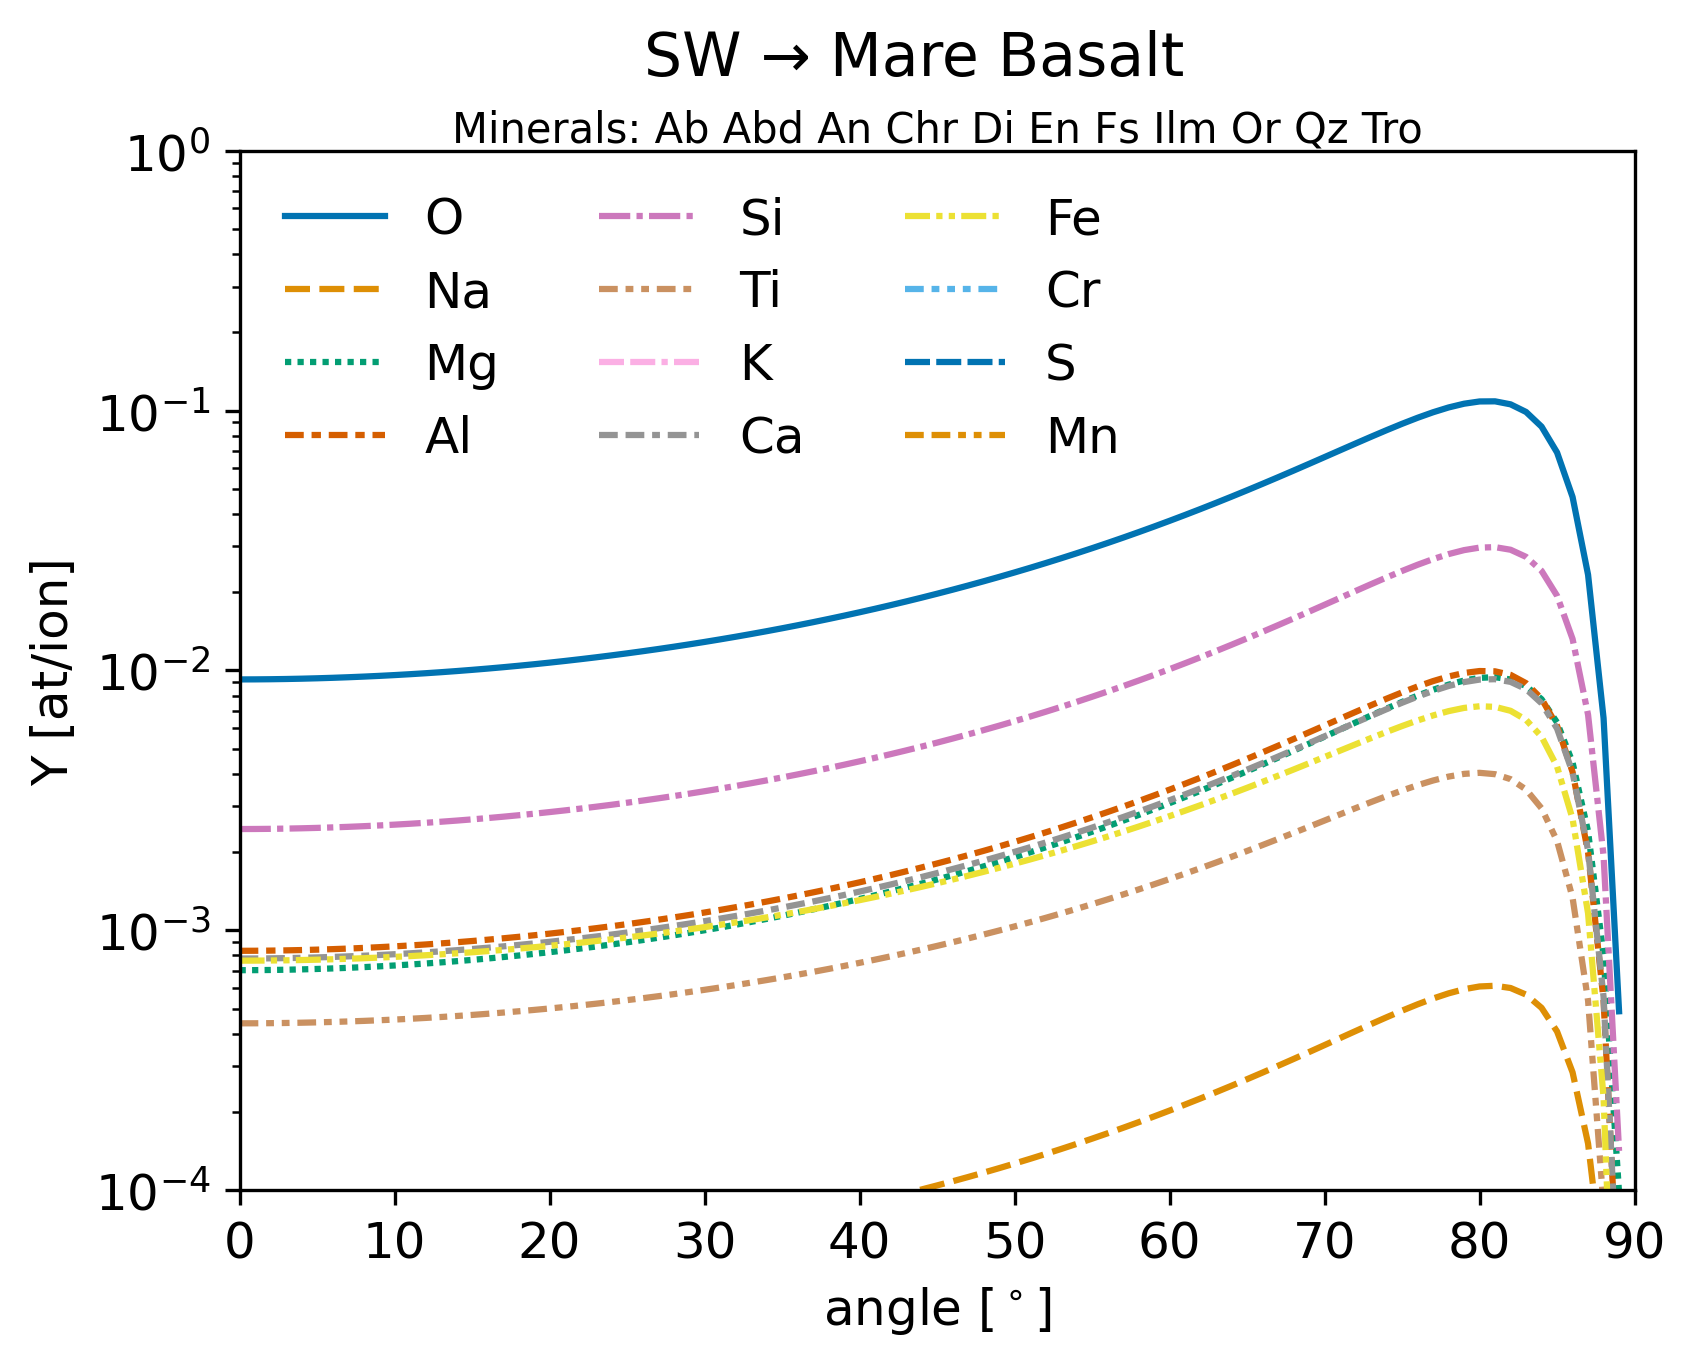

In [13]:
fig, ax = SpuBase.plot_yield()
fig

In [14]:
SpuBase.dist_angle = 60 # set distribution angle (default: 45°)
SpuBase.sputtered_particles_data()

Plotting angular distribution


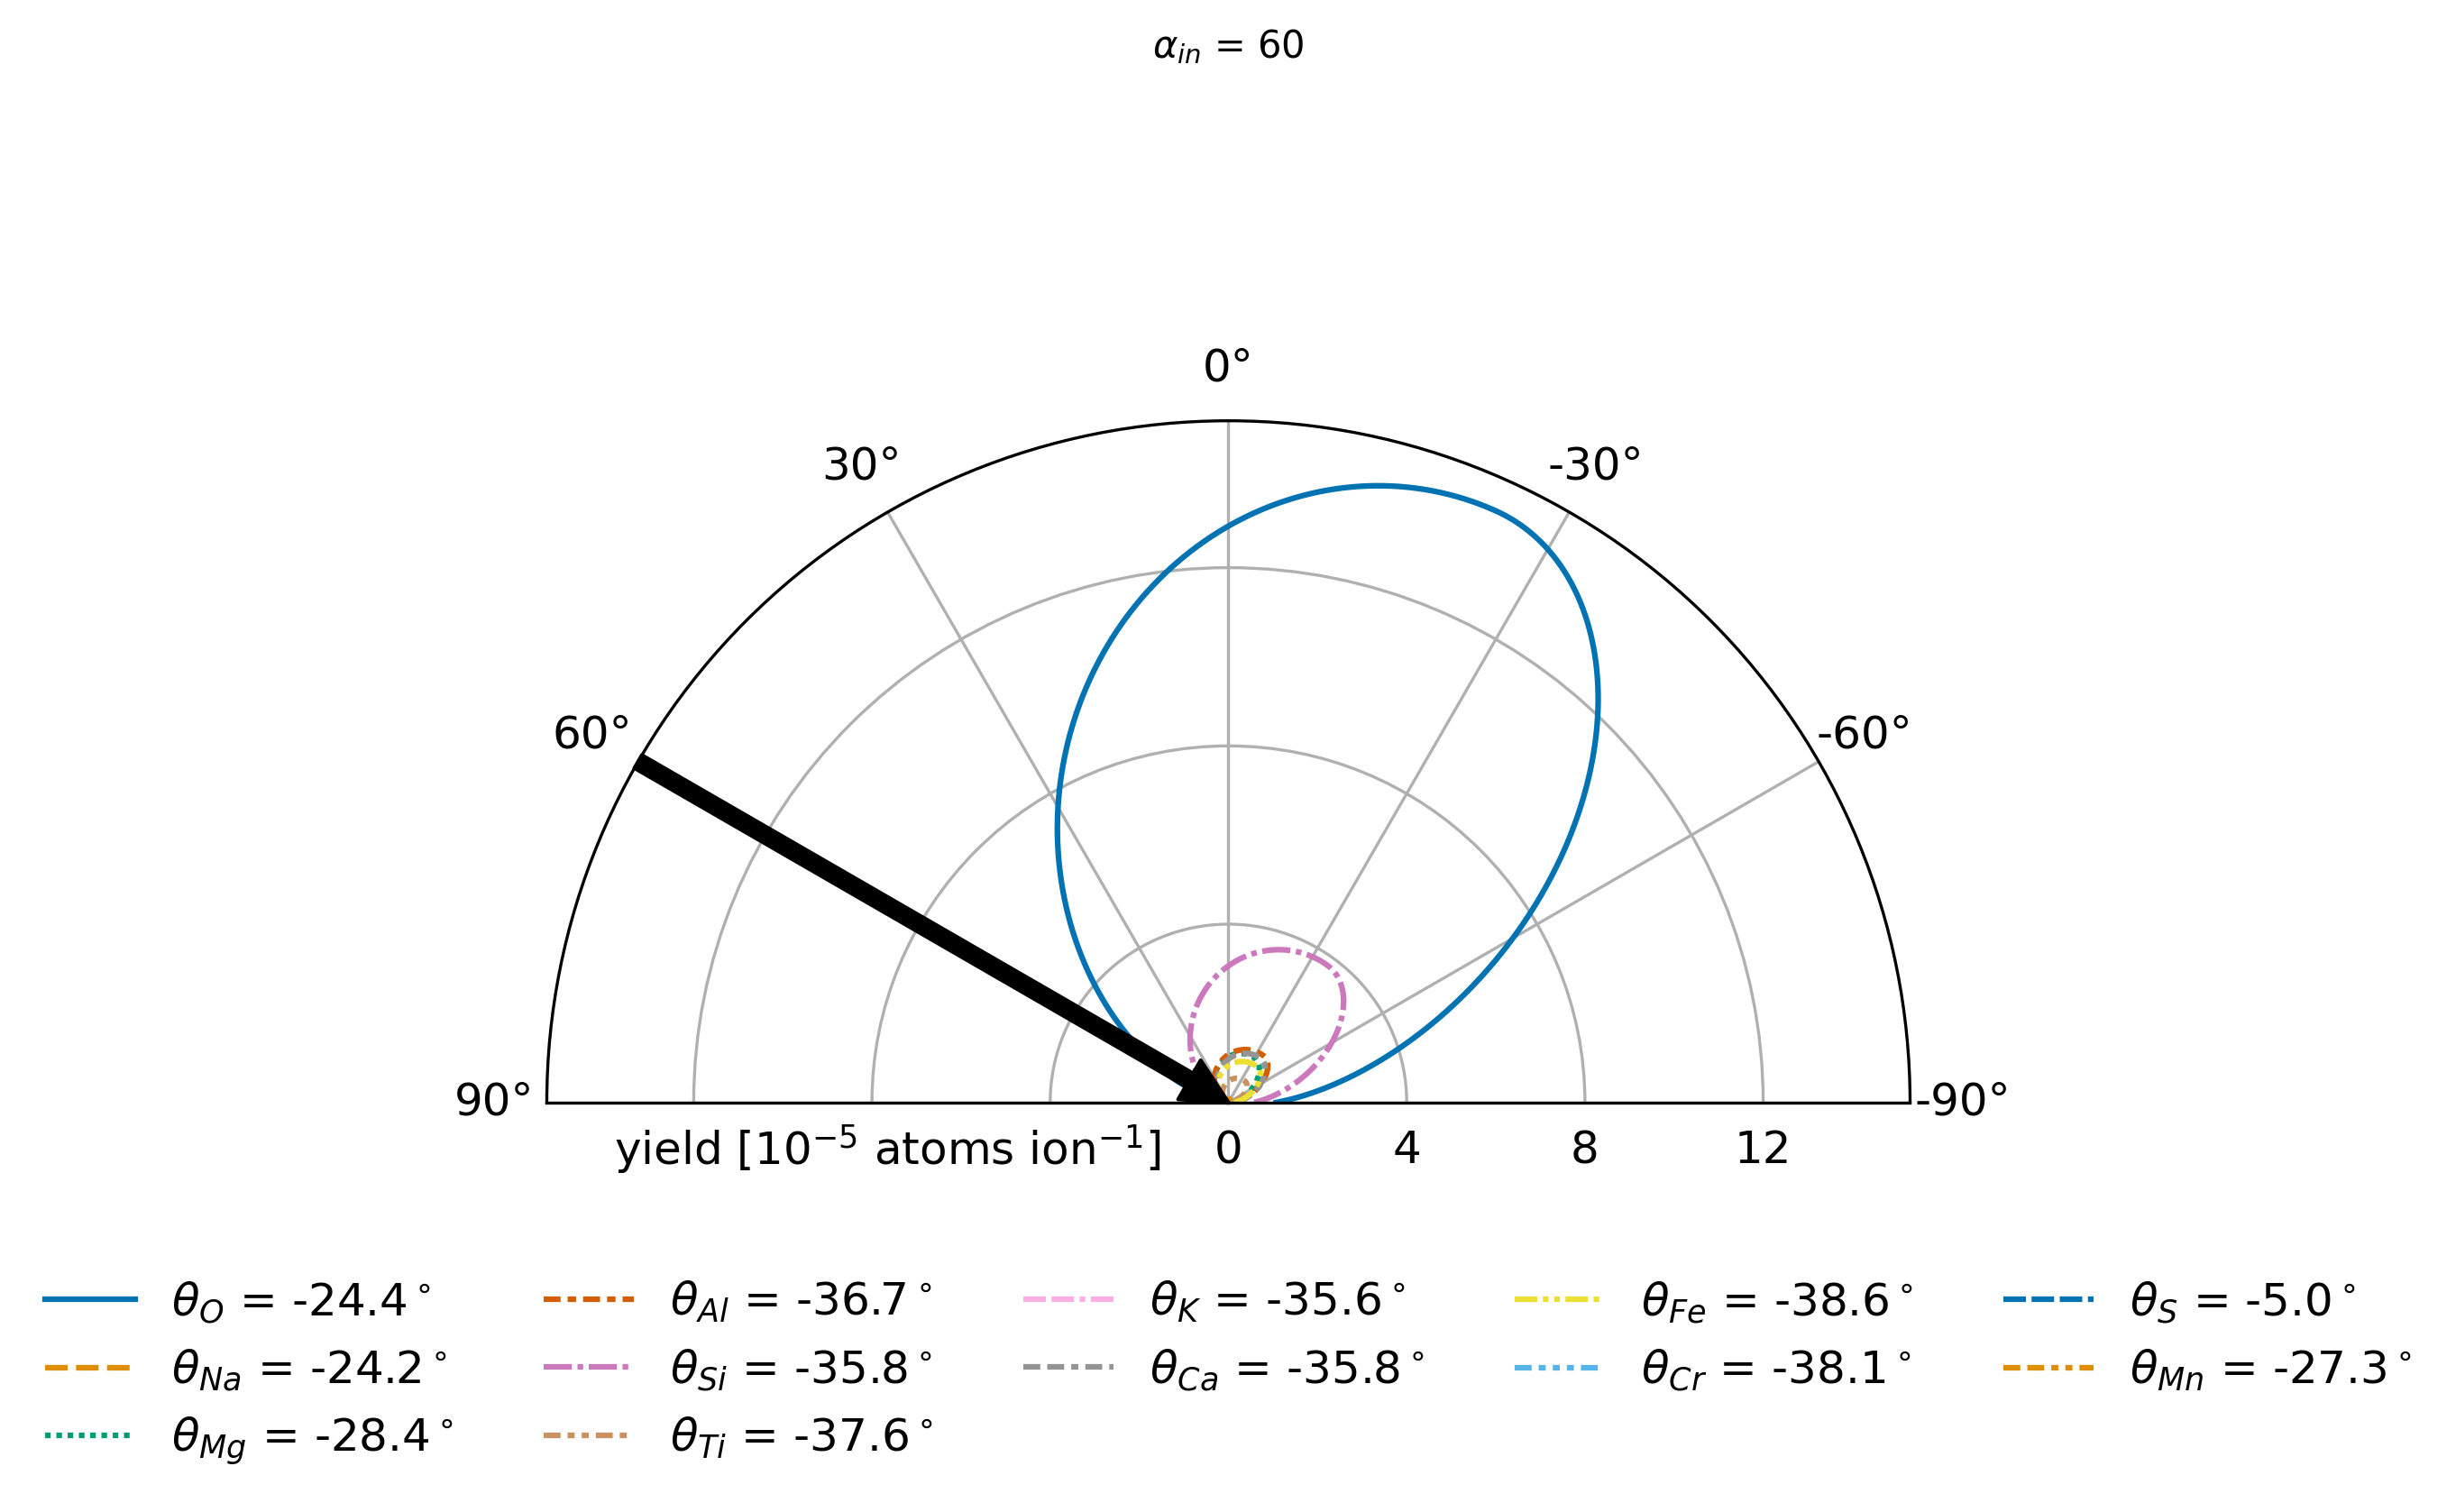

In [15]:
fig_adist, ax_adist = SpuBase.plot_dist('angular', title='')
fig_adist

Plotting energy distribution


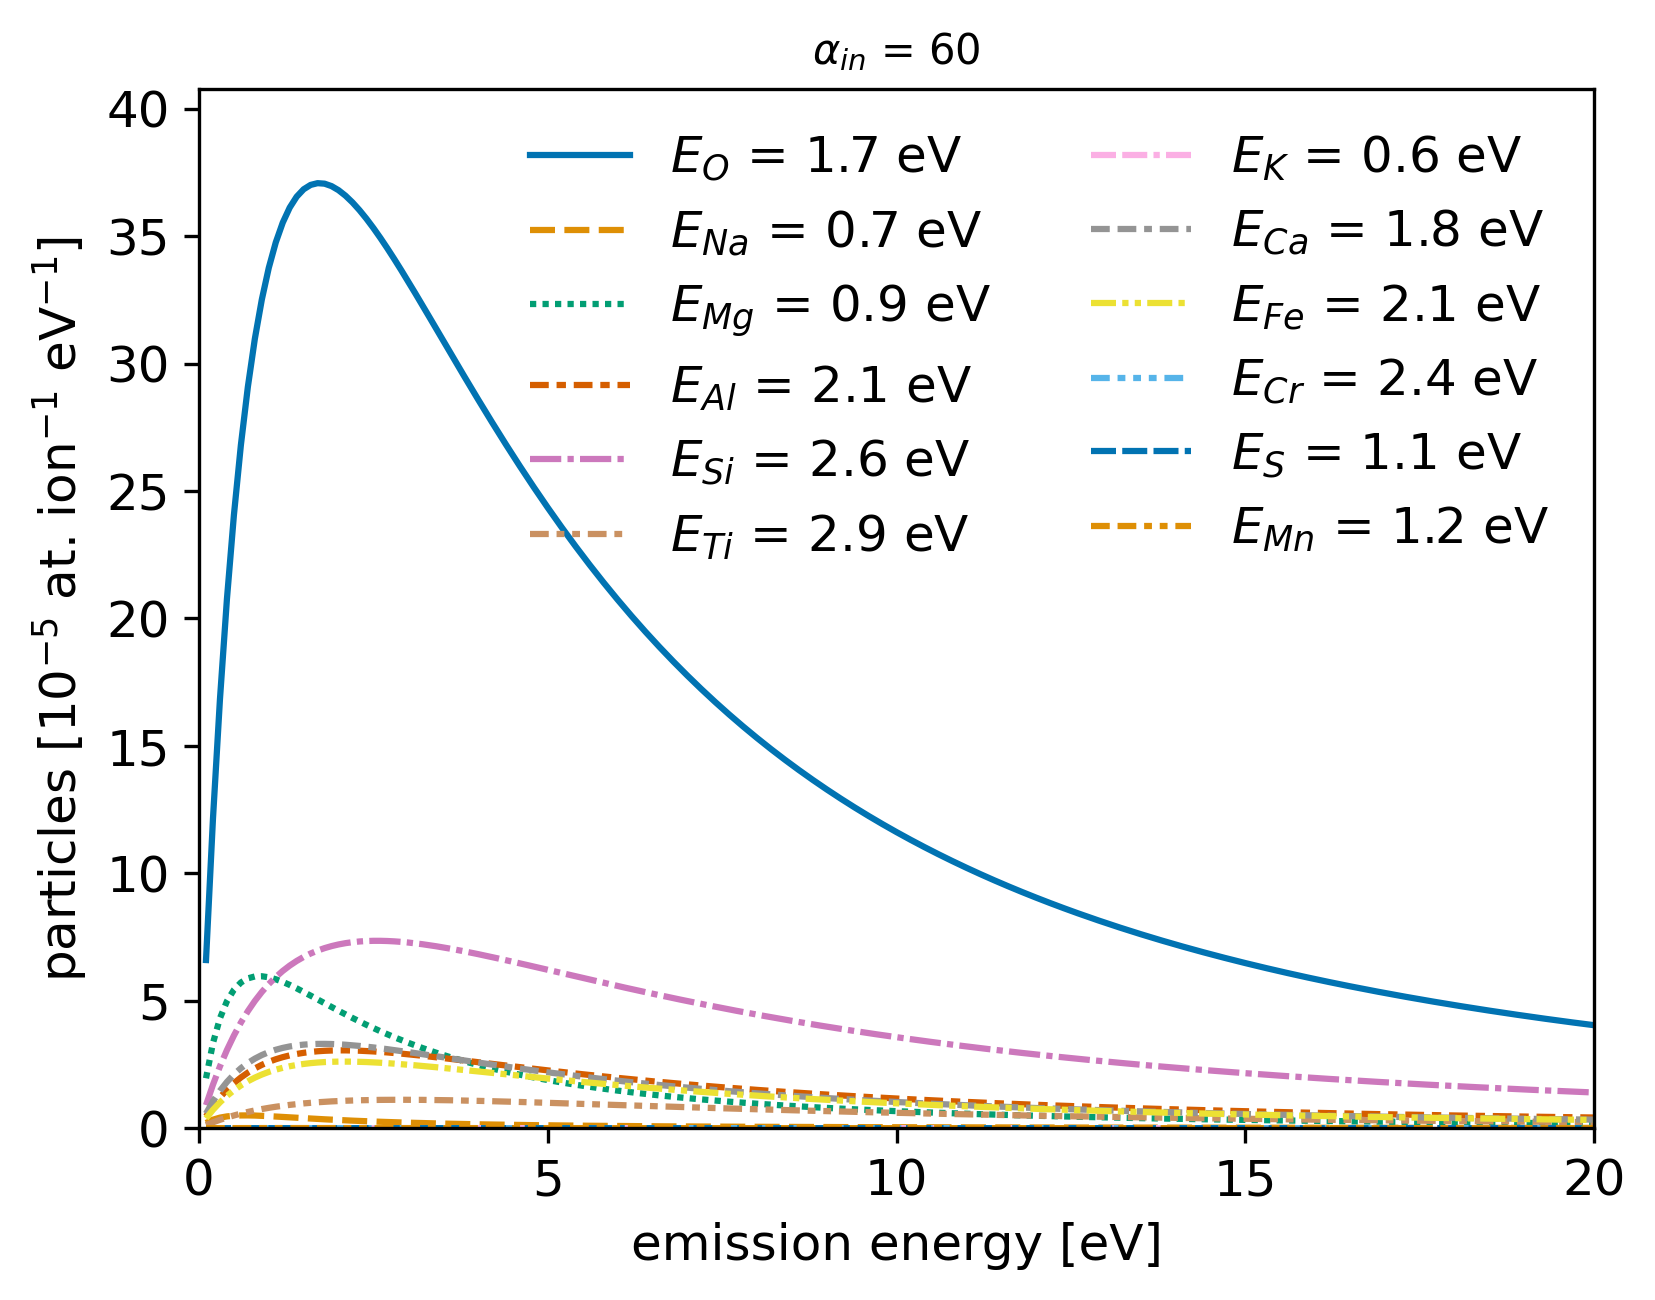

In [16]:
fig_edist, ax_edist = SpuBase.plot_dist('energy', title='')
fig_edist

Plotting plume distribution


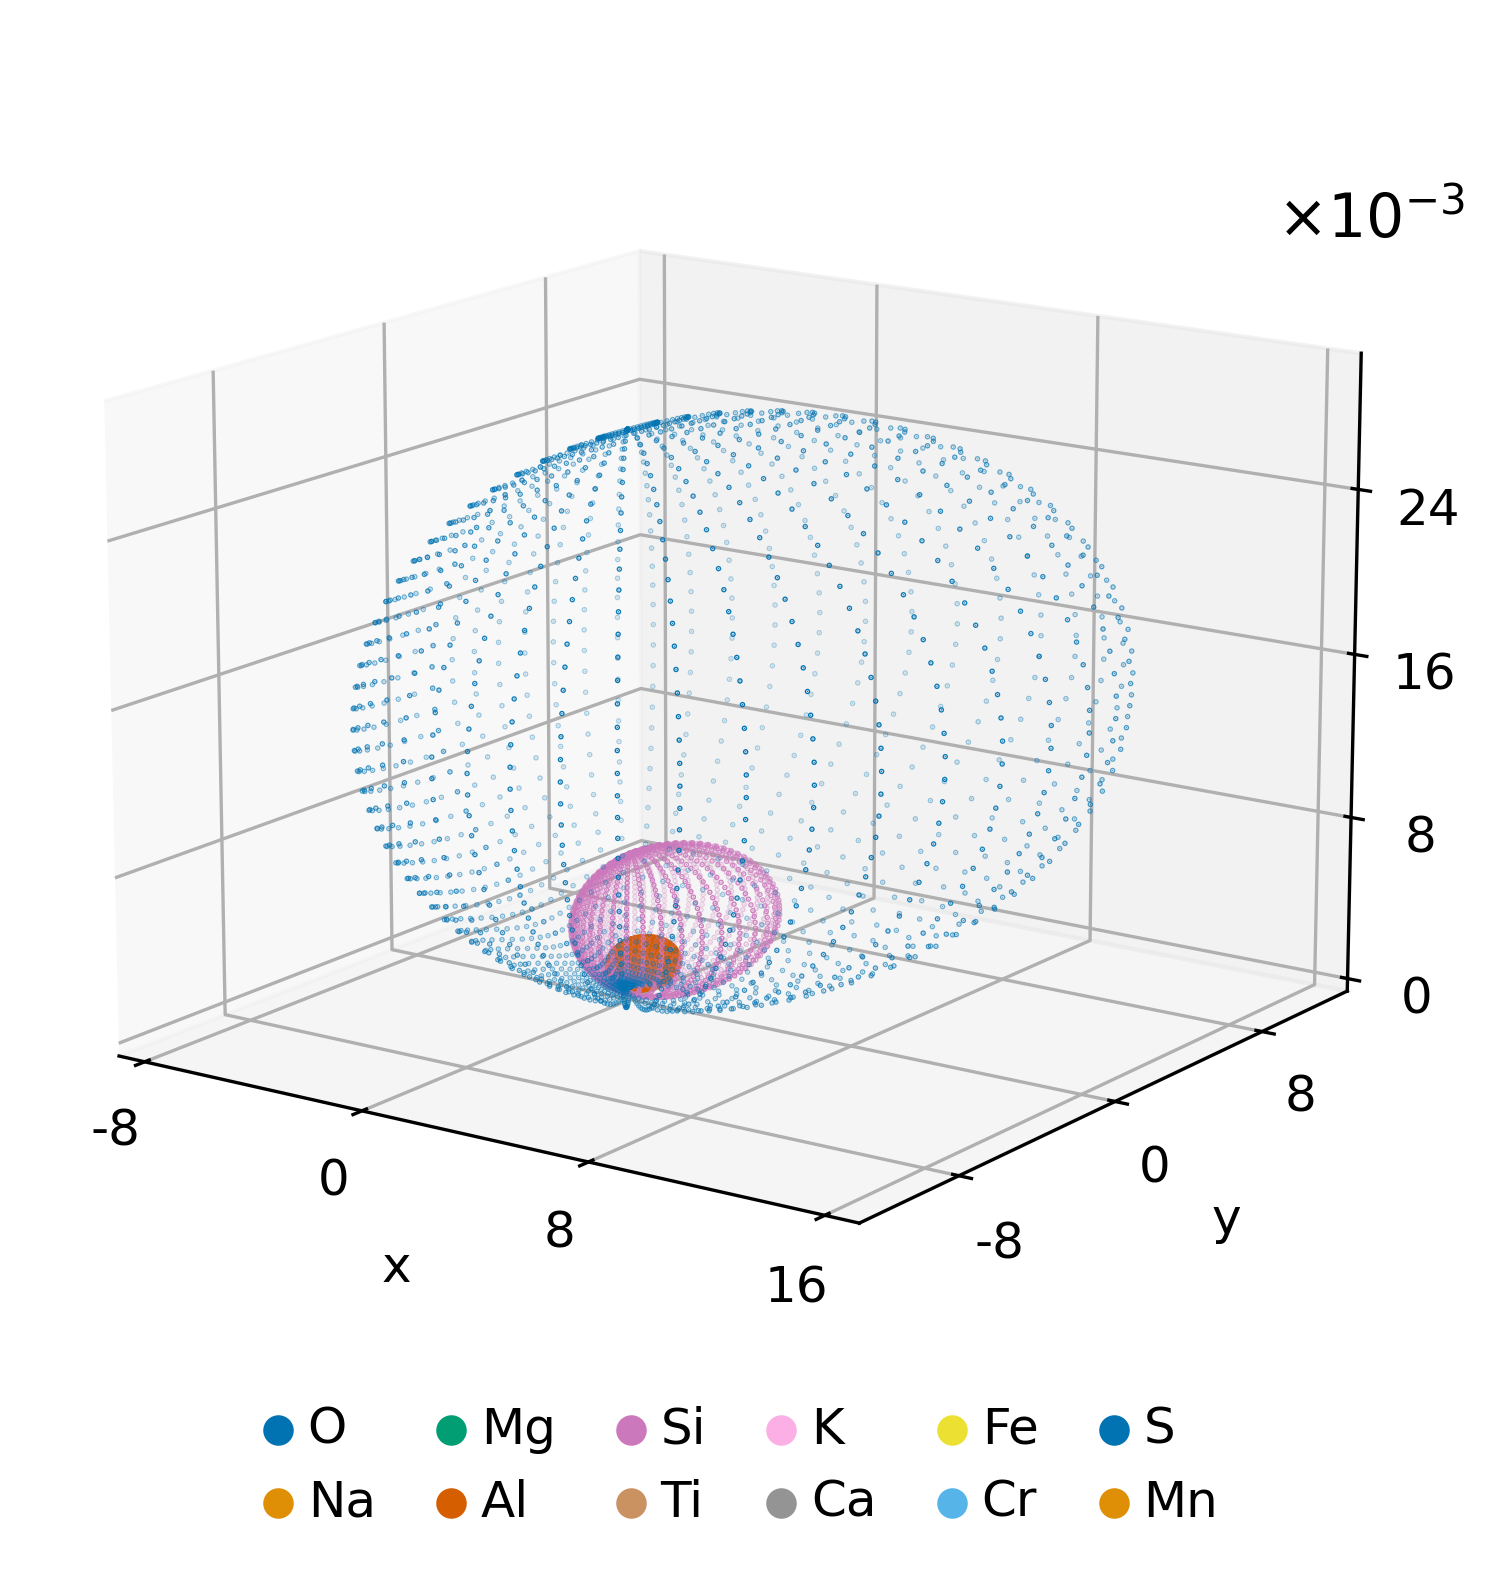

In [25]:
fig_pdist, ax_pdist = SpuBase.plot_dist('plume', title='', elev=15, azim=-55)
fig_pdist

Plotting surface_plume distribution


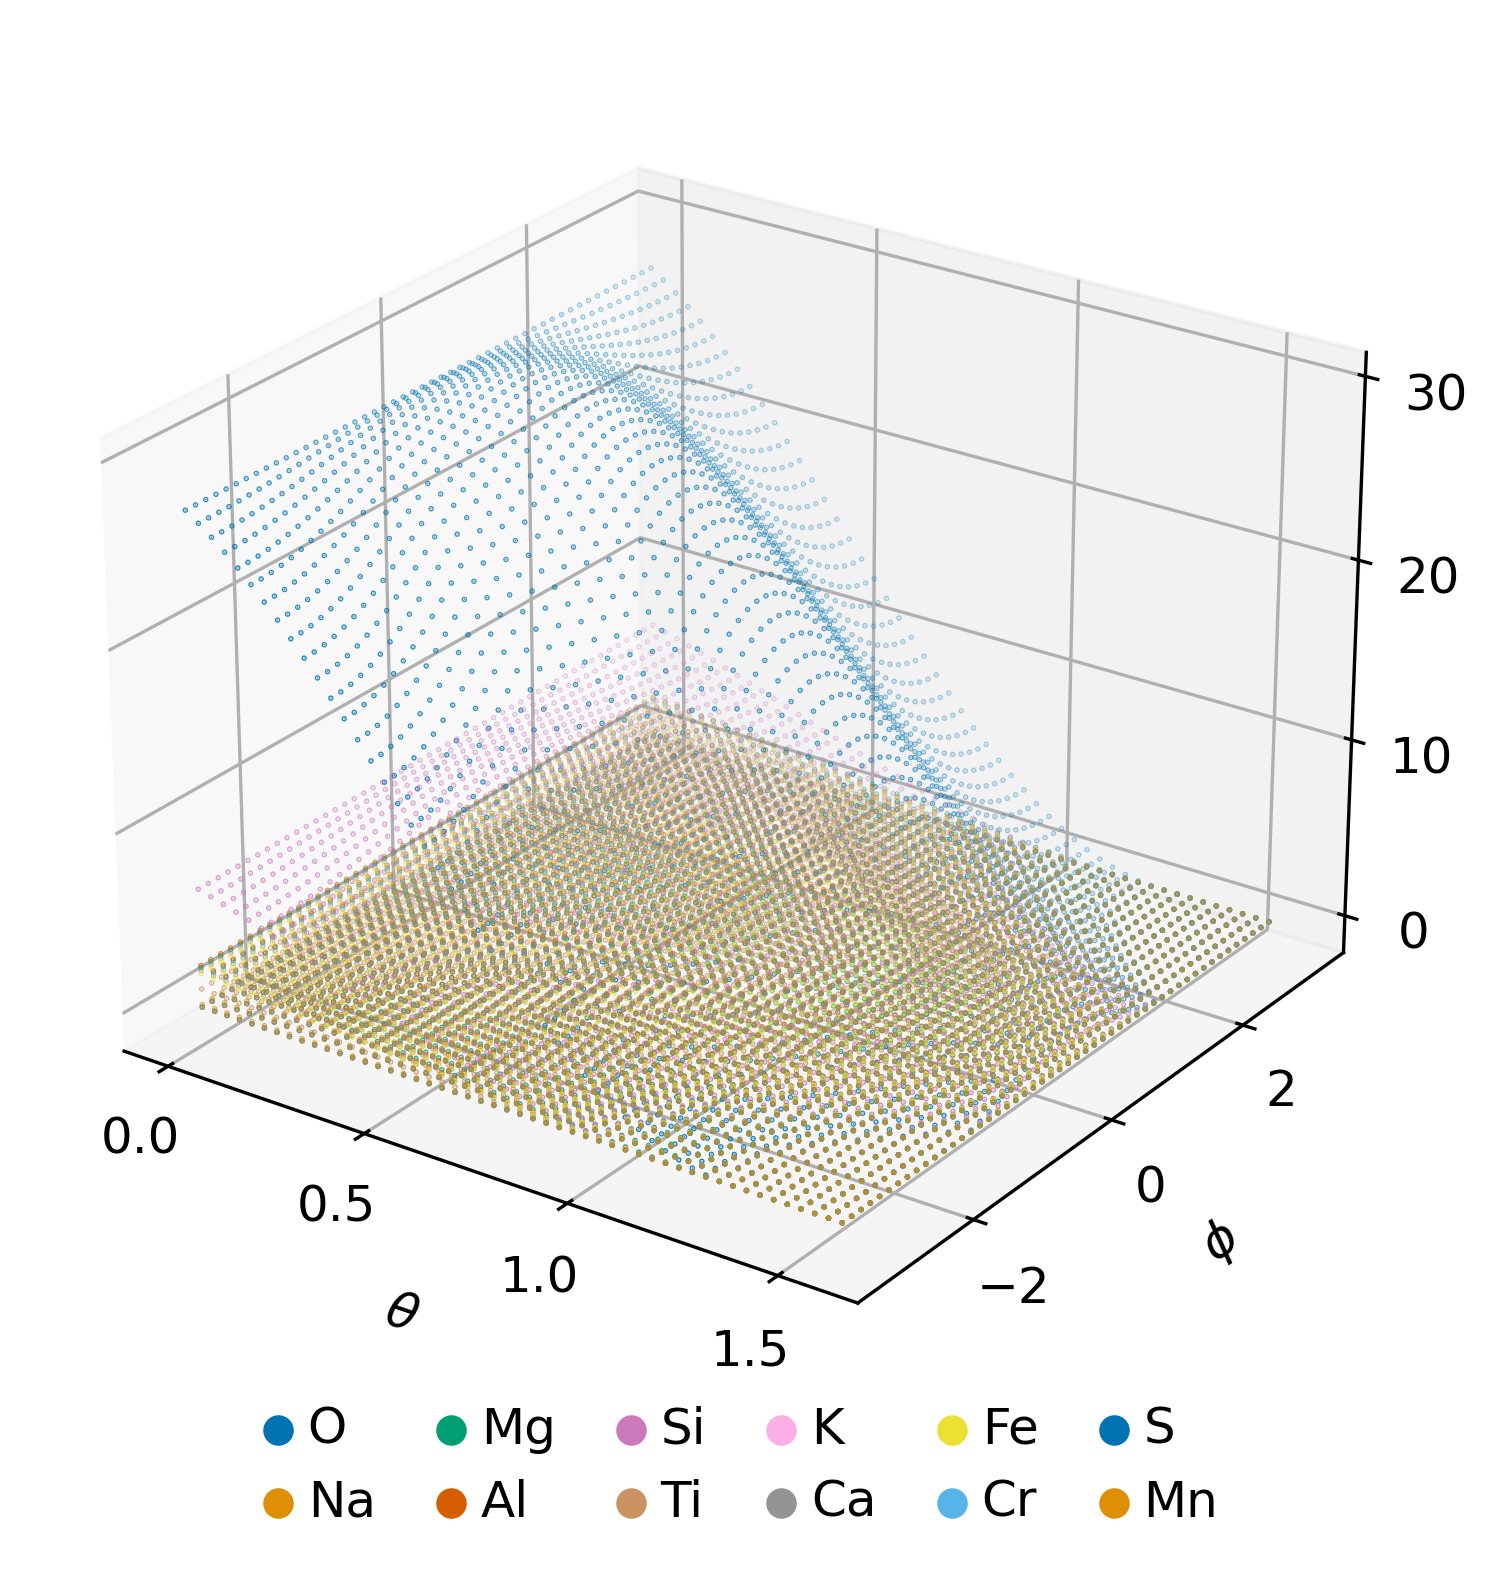

In [26]:
fig_psdist, ax_psdist = SpuBase.plot_dist('surface_plume', title='', elev=25, azim=-55)
fig_psdist